# n005 — Artifact Categories

This notebook analyses the **distribution of artifact categories** across conditions and over time. Each artifact is assigned an integer category (1–4) by an LLM; this notebook aggregates those labels and visualises how the category mix evolves.

**REQUIRES:** `005_artifact_classification.py` to be run first.

**Outputs** (saved to `<ROOT>/plots/`):
- `007_artifact_classification.pdf` — cumulative category counts over time
- `007_artifact_classification_normalize.pdf` — normalized cumulative category counts over time
- `007_artifact_classification_boxplots.pdf` — grouped boxplot of per-category percentage per run, one box per (category, condition) pair
- `007_artifact_classification_boxplots_grouped.pdf` — same but collapsed into two category groups (1–2 vs 3–4)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from core.utils import ROOT
from core.utils.analysis_utils import get_exp_folders
from collections import defaultdict
import io
import json
from typing import List, Dict
import contextlib
from analysis_scripts.artifact_complexity import ExperimentArtifacts
from tqdm import tqdm

# force reload these everytime
import importlib
importlib.reload(importlib.import_module('analysis_scripts.plot_utils'))
from analysis_scripts.plot_utils import color_map, plot_params

plt.rcParams.update(plot_params)

## Configuration

Set `EXP_BASE_NAMES` to the list of experiment base names you want to compare. All matching completed runs under `ROOT/logs/` are collected automatically.

- `PLOT_NAMES` — display-friendly labels (defaults to title-cased experiment name).
- `SHOW_STD` — toggle standard-deviation bands on time-series plots.
- `MODEL` — the phylogeny annotation model.

In [ ]:
EXP_BASE_NAMES = [] # TO DEFINE

# Change this if you want other names in the plot
PLOT_NAMES = {exp_name: exp_name.replace("_", " ").title() for exp_name in EXP_BASE_NAMES}

EXP_PATH = ROOT / "logs"
SHOW_STD = False
MODEL = 'claude-haiku-4-5'
experiment_order = list(PLOT_NAMES.keys())


experiments = {}
for base_name in EXP_BASE_NAMES:
    experiments[base_name] = get_exp_folders(log_path=EXP_PATH, 
                                             exp_name=base_name, 
                                             only_completed=True)

## Data Loading

Loads `ExperimentArtifacts` (stdout suppressed) and `artifact_categories.json` for each run. `validate_categories()` checks that every artifact ID in the run has a category entry; runs with missing IDs are skipped with a warning.

Category labels are reorganised into `cat_by_ts = {timestep: [category_int, ...]}` so that per-timestep aggregation is straightforward downstream.

In [3]:
def validate_categories(cats, artifacts):
    art_ids = set(list(artifacts.all_artifacts.keys()))
    cat_ids = set([int(k) for k in cats.keys()])
    missing_in_cats = art_ids - cat_ids
    if len(missing_in_cats) > 0:
        return False, missing_in_cats
    return True, None


In [4]:
categories = defaultdict(list)
f = io.StringIO()
for base_name, exps in experiments.items():
    for exp in tqdm(exps, desc=base_name):
        exp_path = EXP_PATH / exp

        with contextlib.redirect_stdout(f):
            art = ExperimentArtifacts(exp_path=exp_path, embedding_dimensions=512, save_path=exp_path / "artifact_analysis")
            art.load(force_recalc=False)
            art._load_raw_artifacts()
            art.get_artifact_by_creation(force=True)

        with open(exp_path / "artifact_analysis" / "artifact_categories.json", "r") as cat_f:
            cats = json.load(cat_f)

        valid, missing = validate_categories(cats, art)
        if not valid:
            print("WARNING: Missing artifact IDs in categories for", exp, ":\n", missing)
            continue

        cat_by_ts = {}
        for ts, art_ids in art.artifacts_by_creation.items():
            cat_by_ts[ts] = [int(cats[str(art_id)]) for art_id in art_ids]
        categories[base_name].append({'cats': cat_by_ts, "total_arts": len(art.all_artifacts)})

abundant: 100%|██████████| 5/5 [00:00<00:00, 11.64it/s]


## Cumulative Category Counts — Time Series (Raw)

**`mean_counts_for_category(exp_cats, category)`** — for each run, counts artifacts of the given category created at each timestep, takes the cumulative sum, then pads shorter runs with `NaN` before computing the cross-run mean and std.

Plots 4 panels (one per category) with cumulative raw counts over time. Dots mark the final timestep of each individual run. `SHOW_STD` toggles a ±1 std shaded band.

Saved as `007_artifact_classification.pdf` *(overwritten by the normalised version below)*.

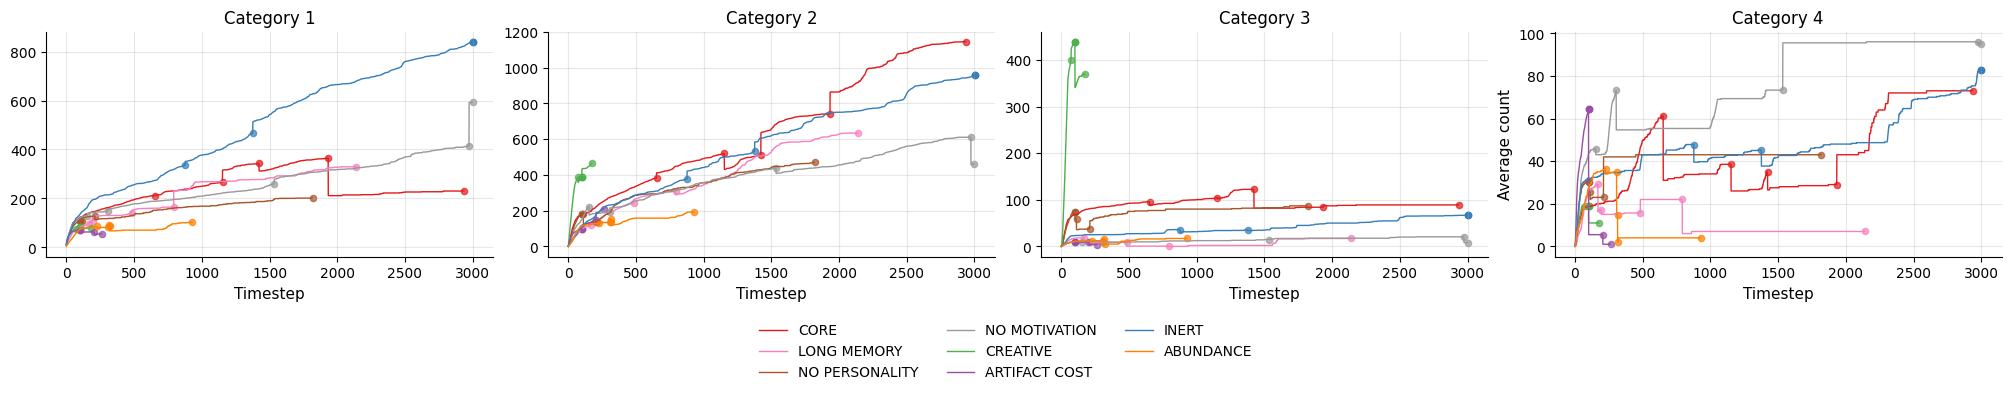

In [ ]:
SHOW_STD = False
# Union of timesteps per base_name across its experiments
ts_by_base = {
    base_name: [max(exp.keys()) for exp in categories[base_name]]
    for base_name in EXP_BASE_NAMES
}

def mean_counts_for_category(exp_cats: List[Dict[int, list]], category: int):
    all_counts = []
    max_ts = 0
    for data in exp_cats:
        counts = []
        for ts, c in data.items():
            counts.append(np.count_nonzero(np.array(c) == category))
        counts = np.cumsum(counts)
        max_ts = max(max_ts, ts)
        all_counts.append(counts)
    
    padded_counts = []
    for count in all_counts:
        padded = np.ones(max_ts+1) * np.nan
        padded[:len(count)] = count
        padded_counts.append(padded)
    mean = np.nanmean(padded_counts, axis=0)
    std = np.nanstd(padded_counts, axis=0)

    exp_ends = [[len(c), mean[(len(c)-1)]] for c in all_counts]

    return np.arange(max_ts+1), mean, std, exp_ends

cats = [1, 2, 3, 4]
fig, axes = plt.subplots(1, len(cats), figsize=(20, 3), constrained_layout=True)

for ax, cat in zip(axes, cats):
    for base_name in EXP_BASE_NAMES:
        if not categories.get(base_name):
            continue
        cat_data = [c['cats'] for c in categories[base_name]]

        x, y, s, exp_ends = mean_counts_for_category(cat_data, cat)
        if x.size == 0 or np.all(np.isnan(y)):
            continue
        color = color_map.get(base_name, "black")
        ax.plot(x, y, label=PLOT_NAMES.get(base_name, base_name), color=color, linewidth=1)

        ax.scatter(*zip(*exp_ends), color=color_map[base_name], alpha=0.7, s=20)

        if SHOW_STD and np.any(s):
            ax.fill_between(x, y - s, y + s, color=color, alpha=0.1)
    ax.set_xlabel("Timestep")
    ax.set_title(f"Category {cat}")
    ax.grid(alpha=0.3)

axes[-1].set_ylabel("Average count")

fig.suptitle("Artifact category counts over time")

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=min(3, len(labels)))
plt.savefig(ROOT / "plots" / "007_artifact_classification.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])

plt.show()

## Cumulative Category Counts — Time Series (Normalised)

Same layout as above, but **`mean_norm_counts_for_category(exp_cats, category)`** divides the cumulative count by `total_arts` before averaging, giving the fraction of all artifacts in the run that belong to each category up to that timestep.

Saved as `007_artifact_classification.pdf` *(overwrites the raw version above)*.

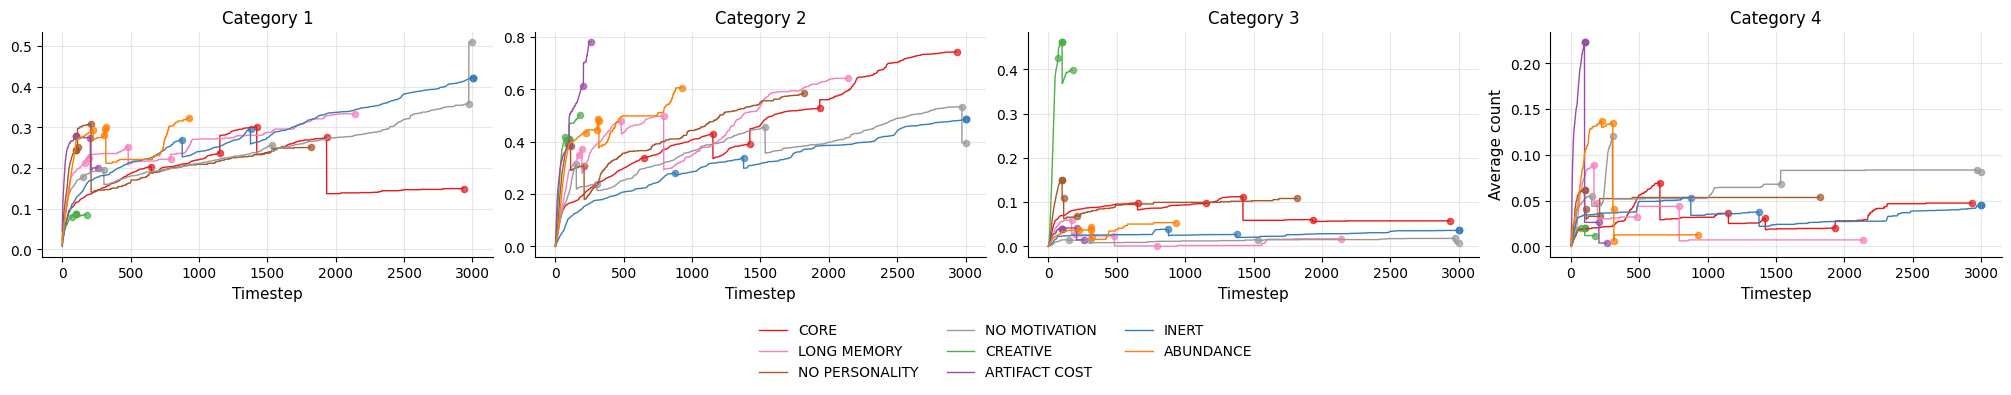

In [ ]:
SHOW_STD = False
# Union of timesteps per base_name across its experiments
ts_by_base = {
    base_name: [max(exp.keys()) for exp in categories[base_name]]
    for base_name in EXP_BASE_NAMES
}

def mean_norm_counts_for_category(exp_cats: List[Dict[int, list]], category: int):
    all_counts = []
    max_ts = 0
    for data in exp_cats:
        categories = data['cats']
        total_arts = data['total_arts']
        counts = []
        for ts, c in categories.items():
            counts.append(np.count_nonzero(np.array(c) == category))
        counts = np.cumsum(counts)/total_arts
        max_ts = max(max_ts, ts)
        all_counts.append(counts)
    
    padded_counts = []
    for count in all_counts:
        padded = np.ones(max_ts+1) * np.nan
        padded[:len(count)] = count
        padded_counts.append(padded)
    mean = np.nanmean(padded_counts, axis=0)
    std = np.nanstd(padded_counts, axis=0)

    exp_ends = [[len(c), mean[(len(c)-1)]] for c in all_counts]

    return np.arange(max_ts+1), mean, std, exp_ends

cats = [1, 2, 3, 4]
fig, axes = plt.subplots(1, len(cats), figsize=(20, 3), constrained_layout=True)

for ax, cat in zip(axes, cats):
    for base_name in EXP_BASE_NAMES:
        if not categories.get(base_name):
            continue
        x, y, s, exp_ends = mean_norm_counts_for_category(categories.get(base_name, []), cat)
        if x.size == 0 or np.all(np.isnan(y)):
            continue
        color = color_map.get(base_name, "black")
        ax.plot(x, y, label=PLOT_NAMES.get(base_name, base_name), color=color, linewidth=1)

        ax.scatter(*zip(*exp_ends), color=color_map[base_name], alpha=0.7, s=20)

        if SHOW_STD and np.any(s):
            ax.fill_between(x, y - s, y + s, color=color, alpha=0.1)
    ax.set_xlabel("Timestep")
    ax.set_title(f"Category {cat}")
    ax.grid(alpha=0.3)

axes[-1].set_ylabel("Average count")
fig.suptitle("Normalized number of artifacts in each category over time")
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=min(3, len(labels)))
plt.savefig(ROOT / "plots" / "007_artifact_classification_normalized.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])

plt.show()

## Per-Category Boxplot

**`artifacts_for_category(exp_cats, category, normalize)`** — pools all artifacts across timesteps for one run and returns the percentage (or raw count if `NORMALIZE=False`) belonging to that category.

Produces a single grouped boxplot: categories on the x-axis, one box per (category, condition) pair. Vertical black lines separate category groups. `SHOW_FLIERS` toggles outlier points.

Saved as `007_artifact_classification_boxplots.pdf`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

SHOW_FLIERS = True  # set False if you want to hide outliers
NORMALIZE = True  # set False if you want absolute counts instead of percentages

def artifacts_for_category(exp_cats: dict[int, list], category: int, normalize=True) -> float:
    """
    exp_cats: {timestep: [cat_id, cat_id, ...], ...}
    returns: percentage of all artifacts in this experiment that are == category
    """
    total = 0
    hits = 0
    for _, cats_at_ts in exp_cats.items():
        arr = np.asarray(cats_at_ts)
        total += arr.size
        hits += np.count_nonzero(arr == category)

    if total == 0:
        return np.nan
    if normalize:
        return 100.0 * hits / total
    else:
        return hits


cats = [1, 2, 3, 4]

# Collect per-experiment percentages:
# data_by_cat_and_base[cat][base_name] = [pct_exp0, pct_exp1, ...]
data_by_cat_and_base = {cat: {} for cat in cats}

for base_name in EXP_BASE_NAMES:
    if not categories.get(base_name):
        continue

    # each element in categories[base_name] is one experiment record
    # and exp['cats'] is the timestep->list structure
    exp_cat_dicts = [exp["cats"] for exp in categories[base_name]]

    for cat in cats:
        vals = [artifacts_for_category(d, cat, normalize=NORMALIZE) for d in exp_cat_dicts]
        vals = [v for v in vals if not np.isnan(v)]  # drop empty experiments
        data_by_cat_and_base[cat][base_name] = vals


# ---- Plot: grouped boxplots (1 figure, 1 axis) ----
base_names = [b for b in EXP_BASE_NAMES if categories.get(b)]
n_bases = len(base_names)

fig, ax = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)

group_centers = np.arange(len(cats))  # 0..3
# spread boxes within each category group
group_width = 0.8
if n_bases > 1:
    offsets = np.linspace(-group_width / 2, group_width / 2, n_bases)
else:
    offsets = np.array([0.0])

box_width = min(0.18, group_width / max(n_bases, 1))

legend_patches = []

for j, base_name in enumerate(base_names):
    color = color_map.get(base_name, "black")
    legend_patches.append(Patch(facecolor=color, edgecolor=color,
                                label=PLOT_NAMES.get(base_name, base_name)))

    for i, cat in enumerate(cats):
        vals = data_by_cat_and_base[cat].get(base_name, [])
        if len(vals) == 0:
            continue

        pos = group_centers[i] + offsets[j]

        bp = ax.boxplot(
            vals,
            positions=[pos],
            widths=box_width,
            patch_artist=True,
            showfliers=SHOW_FLIERS,
            manage_ticks=False
        )

        # style
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.35)
            patch.set_edgecolor(color)
            patch.set_linewidth(1.0)
        for k in ["whiskers", "caps", "medians"]:
            for line in bp[k]:
                line.set_color(color)
                line.set_linewidth(1.0)

# x-axis labels at group centers
ax.set_xticks(group_centers)
ax.set_xticklabels([f"Category {c}" for c in cats])

ax.set_ylabel("Artifacts in category (%)")
ax.set_xlabel("Category")
ax.grid(alpha=0.3, axis="y")

ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, 1.25),
          ncol=min(4, len(legend_patches)), frameon=False)

for i in range(len(cats) - 1):
    ax.axvline(
        x=i + 0.5,
        color="black",
        linewidth=1.2,
        alpha=0.6,
        zorder=0
    )
ax.set_xlim(-0.6, len(cats) - 0.4)
plt.savefig(ROOT / "plots" / "007_artifact_classification_boxplots.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Grouped Categories Boxplot

**`percent_artifacts_for_categories(exp_cats, categories)`** — same as above but accepts a *set* of category IDs, useful for collapsing related categories.

Collapses the four individual categories into two groups (`1–2` and `3–4`) and shows a two-panel boxplot — one panel per group — to highlight high-level splits in artifact type mix across conditions.

Saved as `007_artifact_classification_boxplots_grouped.pdf`.

In [ ]:
base_names = [b for b in EXP_BASE_NAMES if categories.get(b)]
n_bases = len(base_names)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)

group_width = 0.7
offsets = np.linspace(-group_width / 2, group_width / 2, n_bases)
box_width = min(0.25, group_width / max(n_bases, 1))

legend_patches = []

def percent_artifacts_for_categories(exp_cats: dict[int, list], categories: set[int]) -> float:
    total = 0
    hits = 0
    for _, cats_at_ts in exp_cats.items():
        arr = np.asarray(cats_at_ts)
        total += arr.size
        hits += np.count_nonzero(np.isin(arr, list(categories)))

    if total == 0:
        return np.nan
    return 100.0 * hits / total

category_groups = {
    "Categories 1–2": {1, 2},
    "Categories 3–4": {3, 4},
}

group_names = list(category_groups.keys())

data_by_group_and_base = {g: {} for g in group_names}

for base_name in EXP_BASE_NAMES:
    if not categories.get(base_name):
        continue

    exp_cat_dicts = [exp["cats"] for exp in categories[base_name]]

    for gname, gset in category_groups.items():
        vals = [
            percent_artifacts_for_categories(d, gset)
            for d in exp_cat_dicts
        ]
        vals = [v for v in vals if not np.isnan(v)]
        data_by_group_and_base[gname][base_name] = vals

for ax, gname in zip(axes, group_names):
    for j, base_name in enumerate(base_names):
        color = color_map.get(base_name, "black")

        if ax is axes[0]:
            legend_patches.append(
                Patch(facecolor=color, edgecolor=color,
                      label=PLOT_NAMES.get(base_name, base_name))
            )

        vals = data_by_group_and_base[gname].get(base_name, [])
        if not vals:
            continue

        pos = offsets[j]

        bp = ax.boxplot(
            vals,
            positions=[pos],
            widths=box_width,
            patch_artist=True,
            showfliers=True,
            manage_ticks=False
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.35)
            patch.set_edgecolor(color)
        for k in ["whiskers", "caps", "medians"]:
            for line in bp[k]:
                line.set_color(color)
                line.set_linewidth(1.0)

    # panel cosmetics
    # ax.axvline(0, color="black", linewidth=1.2, alpha=0.9, zorder=0)
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    ax.set_title(gname)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Artifacts in category (%)")

fig.legend(
    handles=legend_patches,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=min(4, len(legend_patches)),
    frameon=False
)

plt.savefig(
    ROOT / "plots" / "007_artifact_classification_boxplots_grouped.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()